In [50]:
import pandas as pd

In [63]:
data = pd.read_csv('worlddata_top20_clusting.csv')
df = pd.DataFrame(data)
data

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population,Cluster_n2
0,Afghanistan,58.1,652230,323000,2.1,19101353833,47.9,64.5,38041754,48.9,11.12,9797273,1
1,Albania,43.1,28748,9000,28.1,15278077447,7.8,78.5,2854191,55.7,12.33,1747593,0
2,Algeria,17.4,2381741,317000,0.8,169988236398,20.1,76.7,43053054,41.2,11.70,31510100,1
3,Angola,47.5,1246700,117000,46.3,94635415870,51.6,60.8,31825295,77.5,6.89,21061025,0
4,Argentina,54.3,2780400,105000,9.8,449663446954,8.8,76.5,44938712,61.3,9.79,41339571,1
5,Armenia,58.9,29743,49000,11.7,13672802158,11.0,74.9,2957731,55.6,16.99,1869848,0
6,Australia,48.2,7741220,58000,16.3,1392680589329,3.1,82.7,25766605,65.5,5.27,21844756,0
7,Austria,32.4,83871,21000,46.9,446314739528,2.9,81.6,8877067,60.7,4.67,5194416,0
8,Azerbaijan,57.7,86600,82000,14.1,39207000000,19.2,72.9,10023318,66.5,5.51,5616165,0
9,The Bahamas,1.4,13880,1000,51.4,12827000000,8.3,73.8,389482,74.6,10.36,323784,0


In [61]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
# 'Cluster_n2'는 예측 대상 변수 (종속 변수)
X = df.drop(columns=['Country', 'Cluster_n2'])
y = df['Cluster_n2']

# 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습용, 테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4

Confusion Matrix:


c:\Users\compro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\compro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\compro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


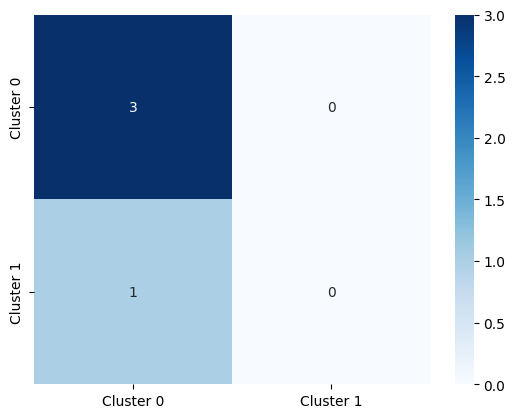

In [65]:
# Linear Discriminant Analysis 모델 학습
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 예측 수행
y_pred = lda.predict(X_test)

# 모델 평가
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Cluster 0", "Cluster 1"], yticklabels=["Cluster 0", "Cluster 1"])
plt.show()
